<a href="https://colab.research.google.com/github/konishogu/DeepLearning-RNNs/blob/main/DLY01100_EV3_003D_GRUPO_5_Entregable_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



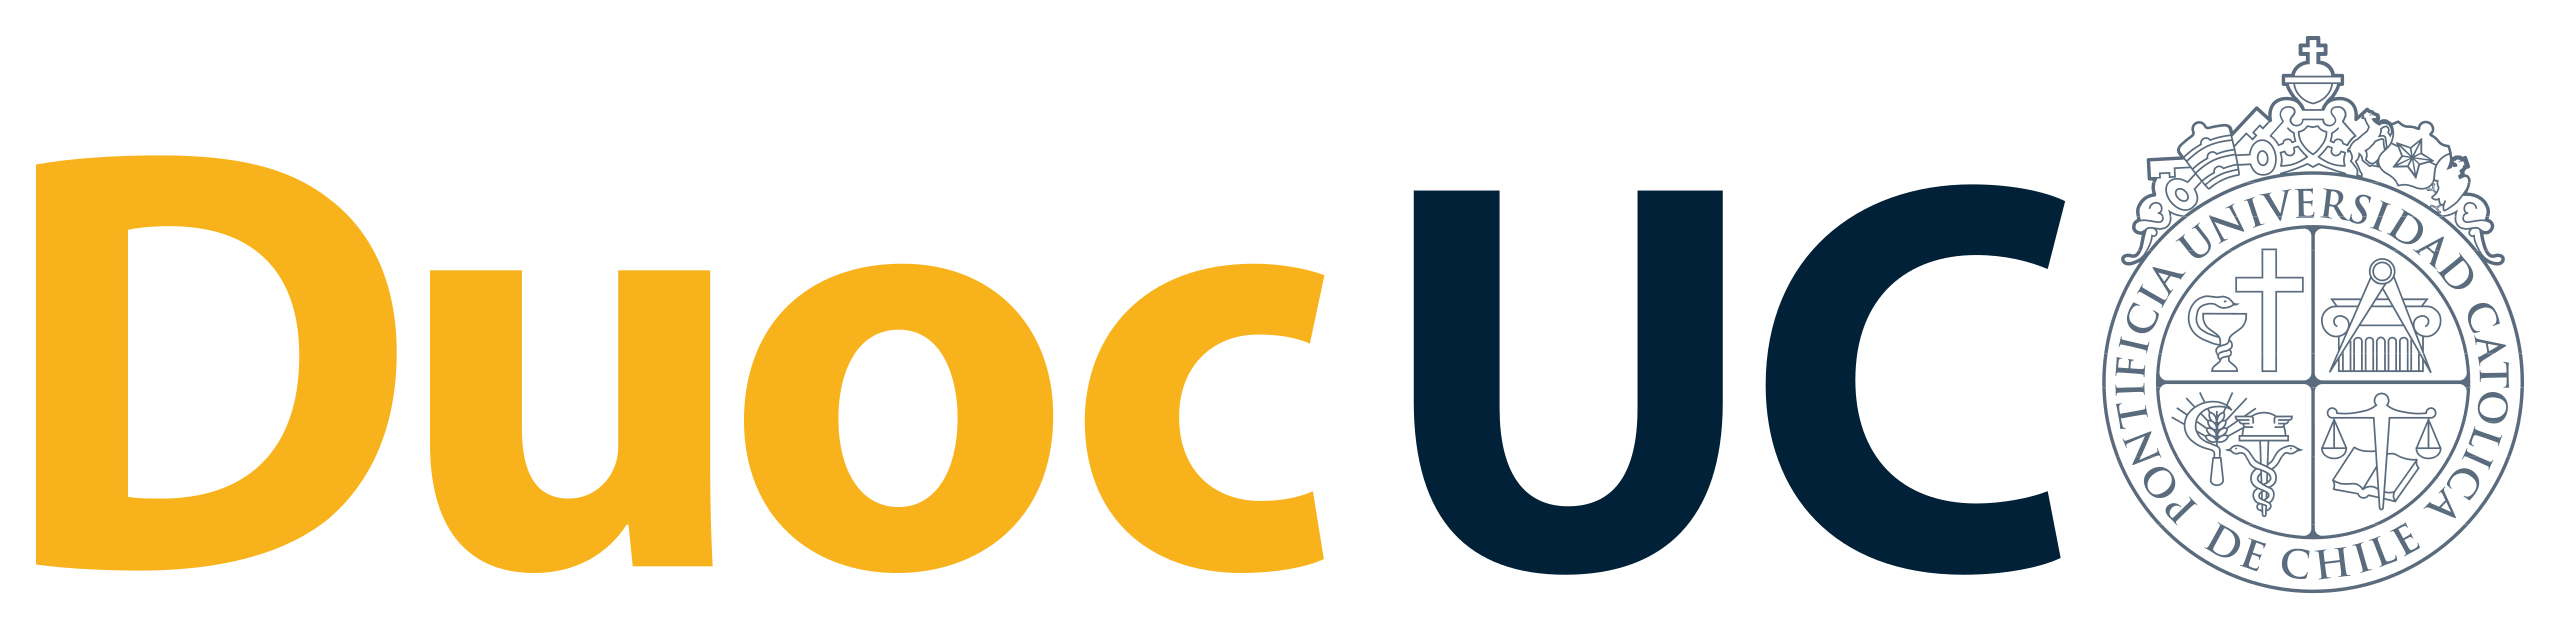



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 28 de Junio de 2026

---

## **1. INTRODUCCIÓN**

En el presente trabajo se desarrollará un modelo de lenguaje basado en Redes Neuronales Recurrentes (RNNs) con el propósito de aprender las características lingüísticas presentes en obras clásicas de la literatura española. Para ello se empleará como corpus principal la obra "El ingenioso Hidalgo Don Quijote de la Mancha" de Miguel de Cervantes, obtenida en formato de texto plano. El proceso contempla la exploración y preprocesamiento del conjunto de texto, la construcción y entrenamiento del modelo neuronal, así como la generación de texto a partir de secuencias iniciales proporcionadas al modelo. De esta manera, se busca analizar la capacidad de las RNNs para capturar patrones sintácticos y estilísticos presentes en textos literarios de gran extensión. Finalmente, se evaluarán los resultados obtenidos mediante el análisis de las secuencias generadas, identificando las fortalezas y limitaciones del modelo en la tarea de generación automática de texto, así como el impacto de distintos parámetros de entrenamiento sobre la calidad de las predicciones producidas.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

## **2. IMPORTACIÓN DE LIBRERÍAS**

En esta etapa se realiza la preparación del entorno de trabajo mediante la importación de las librerías necesarias para el desarrollo del modelo de lenguaje. Estas herramientas permitirán llevar a cabo tareas de procesamiento de datos, construcción de la arquitectura neuronal, entrenamiento del modelo y visualización de resultados.

In [8]:
# Gestión de datos
import pandas as pd

# Operaciones numéricas
import numpy as np

# Framework para aprendizaje profundo
import tensorflow as tf

# Implementación del modelo
import keras

# Modelo secuencial
from keras.models import Sequential

# Capa completamente conectada
from keras.layers import Dense

# Capa para secuencias de texto
from keras.layers import LSTM, SimpleRNN

# Funciones durante el entrenamiento
from keras.callbacks import LambdaCallback

# Optimizador para el entrenamiento del modelo
from keras.optimizers import Adam

# Métricas de evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Visualización de gráficos
import matplotlib.pyplot as plt

# Generación de valores aleatorios
import random

# Manejo de archivos y flujos de texto
import io

# Conteo de frecuencias
from collections import Counter

## **3. CARGA DE LOS DATOS**

### **3.1. Descarga de datos**

En esta etapa se obtiene el corpus textual que será utilizado durante el entrenamiento. Para este trabajo se emplea una versión en formato TXT de la obra "El Ingenioso Hidalgo Don Quijote de la Mancha" de Miguel de Cervantes, previamente depurada para conservar únicamente el contenido narrativo de la novela.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Descargar y almacenar localmente el corpus de entrenamiento
path = keras.utils.get_file(

    # Nombre del archivo
    fname="don_quijote.txt",

    # Fuente de descarga
    origin="https://drive.google.com/uc?export=download&id=1yuCQ6bIU356juJuyPmryX99tNYE7iEex"
)

2151176/2151176 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **3.2. Carga y Normalización de datos**

En esta etapa se carga el contenido completo del archivo de texto en memoria y se almacena en una única variable. Posteriormente, el texto se convierte a minúsculas con el fin de reducir la cantidad de caracteres distintos que el modelo deberá aprender, simplificando así el proceso de entrenamiento y favoreciendo una representación más uniforme del corpus.

In [3]:
# Abrir el archivo en modo lectura
with io.open(path, encoding='utf-8') as f:

    # Leer el contenido del corpus
    text = f.read()

# Convertir todo el texto a minúsculas
text = text.lower()

Una vez cargado el corpus en la variable text, se realiza una inspección inicial para verificar que el contenido fue leído correctamente. Para ello se muestra la longitud total del texto y una muestra de sus primeros caracteres, permitiendo comprobar que el archivo corresponde a la obra esperada y que la conversión a minúsculas se realizó correctamente.

In [5]:
# Mostrar la cantidad total de caracteres del texto
print(f"-----------------------------------------")
print("Longitud del texto: {}".format(len(text)))
print(f"-----------------------------------------")

# Mostrar los primeros 300 caracteres para verificar el contenido
print(text[0:300])

-----------------------------------------
Longitud del texto: 2071198
-----------------------------------------
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más


## **4. EXPLORACIÓN Y ANÁLISIS DE DATOS**

### **4.1. Análisis del vocabulario de caracteres**

Dado que el modelo trabajará a nivel de caracteres, se identifican todos los símbolos únicos contenidos en la obra para construir el vocabulario que utilizará la red neuronal.



In [6]:
# Identificar los caracteres únicos
chars = sorted(list(set(text)))

print(f"-------------------------------------------")
print(f"Cantidad de caracteres únicos: {len(chars)}")
print(f"-------------------------------------------")

# Mostrar todos los registros de la tabla
pd.set_option('display.max_rows', None)

# Crear y visualizar la tabla
df_chars = pd.DataFrame(chars, columns=["Caracter"])
df_chars

-------------------------------------------
Cantidad de caracteres únicos: 61
-------------------------------------------


,Caracter
0,\n
1,
2,!
3,""""
4,'
5,(
6,)
7,","
8,-
9,.


**OBSERVACIÓN:** El análisis del conjunto de texto permitió identificar un total de 61 caracteres únicos. Entre ellos se encuentran letras del alfabeto, espacios, signos de puntuación, caracteres numéricos y símbolos propios del idioma español como las vocales acentuadas, la letra ñ y los signos de apertura de interrogación y exclamación.

### **4.2. Frecuencia de caracteres**

Una vez identificados los caracteres únicos presentes en el conjunto de texto, resulta útil analizar su frecuencia de aparición. Este análisis permite conocer cuáles son los símbolos más utilizados dentro de la obra y comprender mejor la distribución de los datos. Además, proporciona información relevante sobre los patrones que el modelo encontrará con mayor frecuencia durante el entrenamiento.

In [9]:
# Contar la frecuencia de cada carácter
counter = Counter(text)

# Crear una tabla con los 20 caracteres más frecuentes
df_freq = pd.DataFrame(
    [(repr(char), freq) for char, freq in counter.most_common(20)],
    columns=["Caracter", "Frecuencia"]
)

# Mostrar la tabla
df_freq

,Caracter,Frecuencia
0,' ',348116
1,'e',219239
2,'a',191124
3,'o',151442
4,'s',124229
5,'n',107074
6,'r',99644
7,'l',88000
8,'d',86194
9,'u',77257


**OBSERVACIÓN:** El análisis de frecuencias muestra que los caracteres más comunes corresponden al espacio en blanco y a letras frecuentemente utilizadas en el idioma español, destacando las vocales y consonantes como e, a, o, s y n. Asimismo, se observa la presencia de signos de puntuación y saltos de línea, lo que permitirá al modelo aprender no solo patrones léxicos, sino también aspectos relacionados con la estructura y formato del texto.

### **4.3. Análisis a nivel de palabra**

Además del análisis a nivel de caracteres, resulta útil conocer la cantidad aproximada de palabras presentes en el corpus. Este indicador permite dimensionar el volumen de información disponible para el entrenamiento y comprender mejor la magnitud de la obra utilizada como fuente de aprendizaje para el modelo de lenguaje.

In [10]:
# Obtener las palabras
words = text.split()

print(f"Número de palabras: {len(words):,}")

Número de palabras: 376,500


### **4.4. Frecuencia de palabras**

Con el objetivo de comprender mejor el contenido del conjunto de texto, se analiza la frecuencia de aparición de las palabras presentes en la obra. Este análisis permite identificar el vocabulario más utilizado y reconocer patrones lingüísticos característicos del texto.

In [11]:
# Contar la frecuencia de cada palabra
word_counts = Counter(words)

# Crear una tabla con las 20 palabras más frecuentes
df_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Palabra", "Frecuencia"]
)

# Mostrar la tabla
df_words

,Palabra,Frecuencia
0,que,19273
1,de,17892
2,y,16290
3,la,10201
4,a,9641
5,el,8036
6,en,8019
7,no,5706
8,los,4688
9,se,4643


**OBSERVACIÓN:** El análisis de frecuencia de palabras muestra que los términos más comunes corresponden principalmente a artículos, preposiciones y conectores propios del idioma español, destacando palabras como "que", "de", "y", "la" y "el". Esta distribución es coherente con la estructura lingüística de textos narrativos extensos. Asimismo, se observa la presencia de términos característicos de la obra, como "don", lo que evidencia que el contenido conserva elementos representativos de la novela.

## **5. PROCESAMIENTO DE LOS DATOS**

Dado que el modelo de lenguaje será entrenado a nivel de caracteres, no es necesario realizar una tokenización basada en palabras. En su lugar, cada carácter del conjunto de texto, incluyendo, espacios y signos de puntuación, será utilizado como unidad básica de aprendizaje. Con el objetivo de entrenar la red neuronal, el texto debe transformarse en ejemplos de entrada y salida. Para ello, se generan secuencias de longitud fija (SEQ_LENGTH) que servirán como entrada al modelo, mientras que el carácter inmediatamente posterior a cada secuencia corresponderá a la salida esperada. En este trabajo se emplea un enfoque de tipo secuencia a carácter, donde la red recibe una secuencia de caracteres y aprende a predecir el siguiente carácter de la obra.

### **5.1. Construcción del vocabulario de caracteres**

Debido a que el modelo trabajará con texto a nivel de caracteres, es necesario transformar cada carácter del corpus en una representación numérica que pueda ser procesada por la red neuronal. Para ello, se identifico en la sección de exploración los caracteres únicos presentes en la obra y en este apartado se construyen dos diccionarios de correspondencia: uno que asigna un índice numérico a cada carácter y otro inverso que permite recuperar el carácter original a partir de dicho índice.

In [12]:
# Crear mapa de caracteres a índices
char_to_idx = {char: idx for idx, char in enumerate(chars)}

# Crear mapa inverso de índices a caracteres
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(f"----------------------------------------------------")
print("Ejemplo de mapa carácter a índice:")
print(f"----------------------------------------------------")
print(list(char_to_idx.items())[:5])

print(f"----------------------------------------------------")
print("Ejemplo de mapa índice a carácter:")
print(f"----------------------------------------------------")
print(list(idx_to_char.items())[:5])
print(f"----------------------------------------------------")

----------------------------------------------------
Ejemplo de mapa carácter a índice:
----------------------------------------------------
[('\n', 0), (' ', 1), ('!', 2), ('"', 3), ("'", 4)]
----------------------------------------------------
Ejemplo de mapa índice a carácter:
----------------------------------------------------
[(0, '\n'), (1, ' '), (2, '!'), (3, '"'), (4, "'")]
----------------------------------------------------


### **5.2. Generación de secuencias de entrenamiento**

Para preparar los datos que serán utilizados por la red, el corpus textual se divide en pequeñas secuencias de caracteres de longitud fija (SEQ_LENGTH). Cada secuencia será utilizada como entrada del modelo, mientras que el carácter inmediatamente posterior será la salida esperada. Este procedimiento permite crear ejemplos de entrenamiento donde la red aprende a predecir el siguiente carácter dentro del texto.

In [14]:
# Definir tamaño de la secuencia
SEQ_LENGTH = 30

# Crear listas de entrada y salida
sequences = []
next_chars = []

# Generar secuencias de entrenamiento
for i in range(0, len(text) - SEQ_LENGTH):

    # Guardar secuencial actual
    sequences.append(text[i: i + SEQ_LENGTH])

    # Guardar siguiente caracter a predecir
    next_chars.append(text[i + SEQ_LENGTH])

Luego de generar las secuencias de entrada y los caracteres objetivos, se verifica la cantidad de ejemplos creados para conocer el tamaño del conjunto de entrenamiento disponible para el modelo.

In [15]:
print("Tamaño del conjunto de entrenamiento:", len(sequences))

Tamaño del conjunto de entrenamiento: 2071168


Debido al gran tamaño del conjunto de texto de la obra y la cantidad de secuencias generadas, se limita el número de ejemplos utilizados durante el entrenamiento para reducir el consumo de memoria y mejorar el tiempo de ejecución. Para evitar perder representatividad del texto, las secuencias son mezcladas aleatoriamente antes de seleccionar el subconjunto utilizado por el modelo.

In [16]:
# Definir máximo de secuencias
MAX_SEQUENCES = 400000

# Generar orden aleatorio
perm = np.random.permutation(len(sequences))

# Convertir listas a arreglos NumPy
sequences, next_chars = np.array(sequences), np.array(next_chars)

# Mezclar las secuencias
sequences, next_chars = sequences[perm], next_chars[perm]

# Seleccionar una muestra de secuencias
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

# Mostrar cantidad final de secuencias
print(len(sequences))

400000


### **5.3. Codificación de datos para el modelo**

Una vez generadas las secuencias de entrenamiento y los caracteres objetivo, es necesario transformar esta información a un formato numérico que pueda ser procesado por la red neuronal. Para ello, se utiliza la técnica de One-Hot Encoding, que representa cada carácter mediante un vector binario donde únicamente una posición toma el valor 1 y el resto permanecen en 0. Como resultado, se construyen los arreglos X e y, donde X contiene las secuencias de entrada codificadas e y almacena el carácter que el modelo deberá predecir.



In [17]:
# Cantidad de caracteres únicos
NUM_CHARS = len(chars)

# Cantidad de secuencias
NUM_SEQUENCES = len(sequences)

# Inicializar entrada y salida
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS))
y = np.zeros((NUM_SEQUENCES, NUM_CHARS))

# Aplicar One-Hot Encoding
for i, seq in enumerate(sequences):

    # Recorrer caracteres de la secuencia
    for t, char in enumerate(seq):

        # Codificar carácter en X
        X[i, t, char_to_idx[char]] = 1

    # Codificar carácter objetivo en y
    y[i, char_to_idx[next_chars[i]]] = 1

# Verificar dimensiones
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (400000, 30, 61)
Forma de y: (400000, 61)


## **6. DEFINICIÓN DEL MODELO Y ENTRENAMIENTO**

En esta etapa se define la arquitectura de la red neuronal que será utilizada para el modelo de lenguaje. A partir de los datos preparados durante el preprocesamiento, se construye una red basada en una capa LSTM encargada de aprender los patrones presentes en las secuencias de caracteres, seguida de una capa de salida que permitirá predecir el siguiente carácter de la secuencia.

Una vez definida la arquitectura, el modelo se configura especificando la función de pérdida, el optimizador y las métricas de entrenamiento. Posteriormente, se realiza un entrenamiento inicial con el propósito de verificar que la red aprende correctamente a partir de los datos y que la función de pérdida disminuye progresivamente, confirmando que el proceso de aprendizaje se está desarrollando de forma adecuada.

In [19]:
# Crear el modelo
model = Sequential()

# Añadir capa LSTM de 128 neuronas
model.add(LSTM(128, input_shape=(SEQ_LENGTH, NUM_CHARS)))

# Añadir capa para predecir el siguiente carácter
model.add(Dense(NUM_CHARS, activation='softmax'))

# Configurar entrenamiento del modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

El resumen del modelo permite verificar que la arquitectura fue creada correctamente. Se observa que la red está compuesta por una capa LSTM de 128 unidades, encargada de procesar las secuencias de caracteres, y una capa Dense de salida con 61 neuronas, cantidad que coincide con los caracteres únicos identificados en el corpus durante la etapa de preprocesamiento. Asimismo, el modelo cuenta con un total de 105.149 parámetros entrenables, lo que indica que todos ellos podrán ajustarse durante el proceso de aprendizaje.

### **6.1. Generación de texto para el seguimiento del entrenamiento**

Con el fin de evaluar el aprendizaje del modelo, en esta etapa se implementa una función que permite generar texto durante el entrenamiento. De esta manera, es posible observar cómo mejora la calidad de las secuencias generadas a medida que el modelo aprende los patrones presentes en el corpus. Para producir un texto más natural y diverso, la selección del siguiente carácter se realiza considerando las probabilidades estimadas por el modelo, en lugar de elegir siempre la opción más probable.

In [ ]:
def sample(probs, temperature=1.0):
    """
    Selecciona el siguiente carácter según las probabilidades
    entregadas por el modelo.
    """

    # Convertir probabilidades a tipo float
    probs = np.asarray(probs).astype('float64')

    # Ajustar probabilidades según la temperatura
    probs = np.log(probs) / temperature

    # Recalcular y normalizar las probabilidades
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Seleccionar un carácter de forma aleatoria
    samples = np.random.multinomial(1, probs, 1)

    # Devolver el índice seleccionado
    return np.argmax(samples)

### **6.2. Implementación del callback para el monitoreo del entrenamiento**

Con el fin de monitorear la evolución del modelo durante el entrenamiento, se implementa un callback que genera automáticamente fragmentos de texto al finalizar cada época. Para ello, se selecciona una secuencia inicial del corpus y el modelo predice los caracteres siguientes utilizando probabilidades aprendidas hasta ese momento. Este procedimiento permite evaluar de forma práctica cómo mejora la calidad y coherencia del texto generado a medida que avanza el proceso de entrenamiento, además de comparar el efecto de distintos valores de temperatura sobre la diversidad de las predicciones.

In [20]:
TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """
    Genera una secuencia de texto a partir de un texto inicial.
    """

    # Guardar el texto generado
    generated = seed_text

    # Generar un carácter en cada iteración
    for i in range(length):

        # Crear la entrada para el modelo
        x_pred = np.zeros((1, SEQ_LENGTH, NUM_CHARS))

        # Codificar la secuencia actual
        for t, char in enumerate(generated[-SEQ_LENGTH:]):
            x_pred[0, t, char_to_idx[char]] = 1

        # Obtener las probabilidades del siguiente carácter
        probs = model.predict(x_pred, verbose=0)[0]

        # Seleccionar el siguiente carácter
        next_index = sample(probs, temperature)

        # Convertir el índice en carácter
        next_char = char_to_idx[next_index]

        # Agregar el carácter al texto generado
        generated += next_char

        # Actualizar la secuencia para la siguiente predicción
        seed_text = seed_text[1:] + next_char

    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Seleccionar un texto inicial aleatorio
  start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
  seed_text = text[start_pos:start_pos + SEQ_LENGTH]

  for temperature in TEMPERATURES_TO_TRY:
    print("------> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(
        seed_text,
        model,
        GENERATED_TEXT_LENGTH,
        temperature
    )

    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()

generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

### **6.3. Entrenamiento del modelo**

Una vez definida la arquitectura de la red neuronal y configurados los mecanismos para monitorear su desempeño, se procede a entrenar el modelo utilizando las secuencias de texto preparadas previamente. Durante este proceso, el modelo ajusta sus parámetros internos a partir de los patrones presentes en el corpus, con el objetivo de aprender las relaciones entre los caracteres y mejorar progresivamente su capacidad para predecir el siguiente carácter de una secuencia.


In [ ]:
# Entrenar el modelo
history_lstm = model.fit(
    # Datos de entrada
    X,
    # Datos de salida
    y,
    # Cantidad de muestras por lote
    batch_size=128,
    # Número de épocas de entrenamiento
    epochs=15,
    # Generar texto al finalizar cada época
    callbacks=[generation_callback]
)

Epoch 1/15
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2835 - loss: 2.4933



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: uadille volviese como solía a 
Texto generado: uadille volviese como solía a de la canta de canta de la canderes de la merchando en la cuanta la cara la viento en en esta la cara de vante de la cara la con la cara de la la canta la veresta la veres de la canta en la cuante de la para la con la verer en que la candere de de la canta de la hante de la cante de la cara de canta

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: uadille volviese como solía a 
Texto generado: uadille volviese como solía a destra de ton la terado se las panderia, y o mondo de sande la deñar estra cualla
talos
y abrar el costa que se mentan con carta la viesto de vuestra poro es que la carabie en de vieston os la dergunor que se cunta de con har pasta y me ver en el cara juenta la cabra a de hancande sa vuento en anten

------> Epoch: 1 - Generando

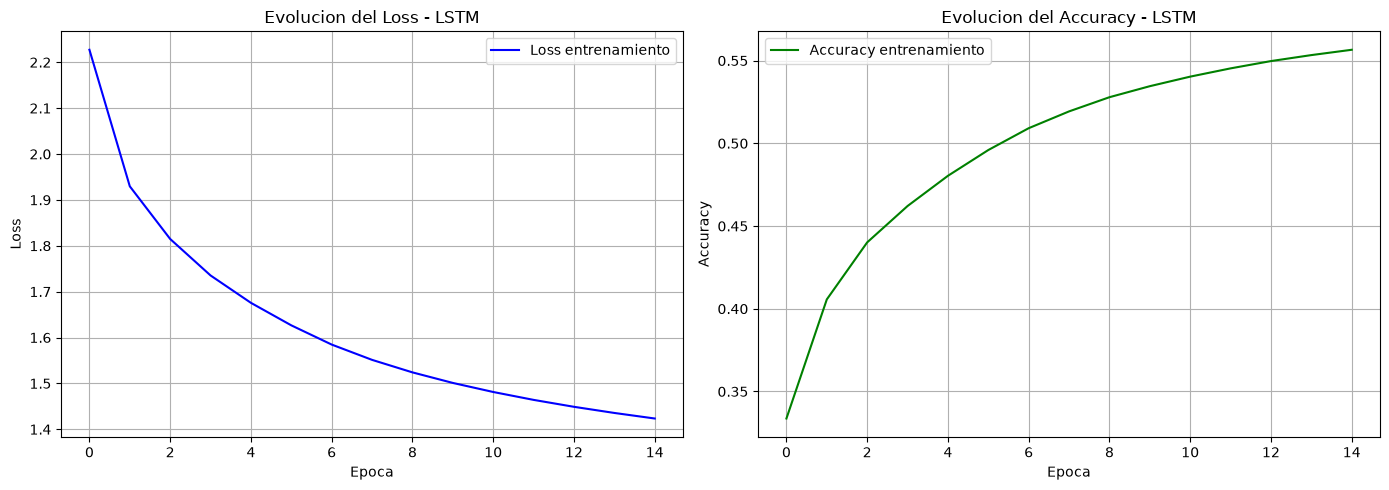

In [ ]:
# Graficamos la perdida y la precision durante el entrenamiento del modelo LSTM

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_lstm.history['loss'], label='Loss entrenamiento', color='blue')
axes[0].set_title('Evolucion del Loss - LSTM')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_lstm.history['accuracy'], label='Accuracy entrenamiento', color='green')
axes[1].set_title('Evolucion del Accuracy - LSTM')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Obtenemos las predicciones del modelo LSTM sobre el conjunto de datos
y_pred_probs_lstm = model.predict(X)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)
y_true = np.argmax(y, axis=1)

# Calculamos las metricas con promedio macro
# se usa macro para que cada clase tenga el mismo peso, independientemente de su frecuencia en el dataset. zero_division=0 evita errores por division entre cero en caso de que alguna clase no tenga predicciones positivas.
acc_lstm = accuracy_score(y_true, y_pred_lstm)
prec_lstm = precision_score(y_true, y_pred_lstm, average='macro', zero_division=0)
rec_lstm = recall_score(y_true, y_pred_lstm, average='macro', zero_division=0)
f1_lstm = f1_score(y_true, y_pred_lstm, average='macro', zero_division=0)

print("=== Metricas del modelo LSTM (128 unidades, 15 epocas) ===")
print(f"Accuracy:  {acc_lstm:.4f}")
print(f"Precision: {prec_lstm:.4f}")
print(f"Recall:    {rec_lstm:.4f}")
print(f"F1-Score:  {f1_lstm:.4f}")

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 76s 6ms/step
=== Metricas del modelo LSTM (128 unidades, 15 epocas) ===
Accuracy:  0.5609
Precision: 0.4610
Recall:    0.3134
F1-Score:  0.3398


## 4. Comparacion de arquitecturas: SimpleRNN vs LSTM

Ahora procedemos a entrenar un modelo SimpleRNN con la misma configuracion (128 unidades, 15 epocas) y comparamos ambos modelos con las mismas metricas.

La diferencia fundamental entre ambas arquitecturas es que la LSTM incorpora compuertas (forget, input, output) que le permiten retener informacion relevante a largo plazo y descartar la que no necesita. La SimpleRNN, en cambio, solo tiene una operacion de activacion simple, lo que la hace mas propensa al problema del desvanecimiento del gradiente en secuencias largas.

In [ ]:
## Definicion del modelo SimpleRNN para comparacion
# Misma estructura que el LSTM: una capa recurrente con 128 unidades + Dense con softmax.
# La unica diferencia es el tipo de capa recurrente.

model_rnn = Sequential()
model_rnn.add(SimpleRNN(128, input_shape=(SEQ_LENGTH, NUM_CHARS)))
model_rnn.add(Dense(NUM_CHARS, activation='softmax'))

model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_rnn.summary()

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,189 (125.74 KB)

 Trainable params: 32,189 (125.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## Entrenamiento del modelo SimpleRNN
# Usamos la misma cantidad de epocas, batch_size y temperaturas para que la comparacion sea justa.

def on_epoch_end_rnn(epoch, logs):
    print("\n\n\n")
    start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
    seed_text = text[start_pos:start_pos + SEQ_LENGTH]
    for temperature in TEMPERATURES_TO_TRY:
        print("------> Epoch: {} - SimpleRNN con temperature {}".format(
            epoch + 1, temperature))
        generated_text = generate_text(seed_text, model_rnn,
                                       GENERATED_TEXT_LENGTH, temperature)
        print("Seed: {}".format(seed_text))
        print("Texto generado: {}".format(generated_text))
        print()

callback_rnn = LambdaCallback(on_epoch_end=on_epoch_end_rnn)


In [ ]:

history_rnn = model_rnn.fit(
    X, y,
    batch_size=128,
    epochs=15,
    callbacks=[callback_rnn]
)

Epoch 1/15
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3014 - loss: 2.4128



------> Epoch: 1 - SimpleRNN con temperature 0.2
Seed: ue encierra en sí todas o las 
Texto generado: ue encierra en sí todas o las cante de la ver a cuna de la mero de la con la ver a de la ver a de la caba le con en en anta de la cabra de de cunta la con la con la con con la caba le de la de la caba la con en anta de se con la con la con la ver a de la con a la de la caba de ver a canta de la caba le de la de la con la cabra d

------> Epoch: 1 - SimpleRNN con temperature 0.5
Seed: ue encierra en sí todas o las 
Texto generado: ue encierra en sí todas o las con la con de cinte la muder, y a dos que de cusa como de la della que se tabia de se viero sen de vue canto que no he la ara la se da la der de de la
de la
caban la bren a con el a cabal en en sas pora de de la cija que sa macra, y en meros, y en al cas su has la mad de los cabar la nos sen harna d

------> Epoch: 1 - SimpleRNN con temperat

In [ ]:
# Metricas del modelo SimpleRNN
y_pred_probs_rnn = model_rnn.predict(X)
y_pred_rnn = np.argmax(y_pred_probs_rnn, axis=1)

acc_rnn = accuracy_score(y_true, y_pred_rnn)
prec_rnn = precision_score(y_true, y_pred_rnn, average='macro', zero_division=0)
rec_rnn = recall_score(y_true, y_pred_rnn, average='macro', zero_division=0)
f1_rnn = f1_score(y_true, y_pred_rnn, average='macro', zero_division=0)

print("=== Metricas del modelo SimpleRNN (128 unidades, 15 epocas) ===")
print(f"Accuracy:  {acc_rnn:.4f}")
print(f"Precision: {prec_rnn:.4f}")
print(f"Recall:    {rec_rnn:.4f}")
print(f"F1-Score:  {f1_rnn:.4f}")

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step
=== Metricas del modelo SimpleRNN (128 unidades, 15 epocas) ===
Accuracy:  0.5256
Precision: 0.4353
Recall:    0.3054
F1-Score:  0.3322



=== Comparacion SimpleRNN vs LSTM ===
Metrica       SimpleRNN       LSTM
----------------------------------
Accuracy         0.5256     0.5609
Precision        0.4353     0.4610
Recall           0.3054     0.3134
F1-Score         0.3322     0.3398


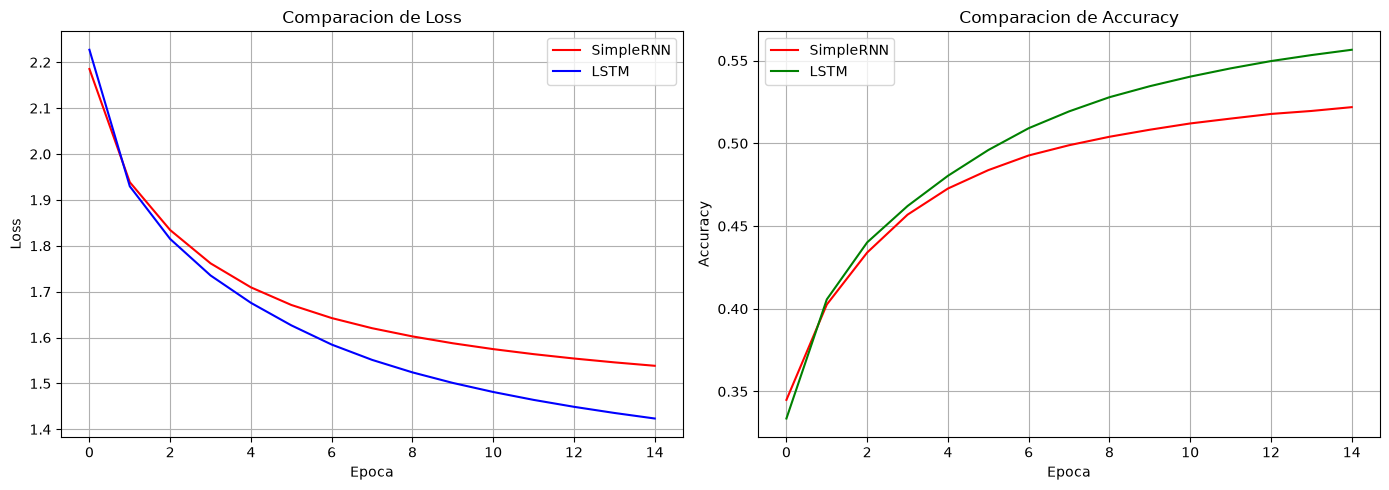

In [ ]:
# Tabla comparativa entre ambos modelos
print("\n=== Comparacion SimpleRNN vs LSTM ===")
print(f"{'Metrica':<12} {'SimpleRNN':>10} {'LSTM':>10}")
print("-" * 34)
print(f"{'Accuracy':<12} {acc_rnn:>10.4f} {acc_lstm:>10.4f}")
print(f"{'Precision':<12} {prec_rnn:>10.4f} {prec_lstm:>10.4f}")
print(f"{'Recall':<12} {rec_rnn:>10.4f} {rec_lstm:>10.4f}")
print(f"{'F1-Score':<12} {f1_rnn:>10.4f} {f1_lstm:>10.4f}")

# Grafico comparativo de loss durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['loss'], label='SimpleRNN', color='red')
axes[0].plot(history_lstm.history['loss'], label='LSTM', color='blue')
axes[0].set_title('Comparacion de Loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_rnn.history['accuracy'], label='SimpleRNN', color='red')
axes[1].plot(history_lstm.history['accuracy'], label='LSTM', color='green')
axes[1].set_title('Comparacion de Accuracy')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Analisis del efecto de la temperatura

-Temperatura 0.2: El modelo repite patrones frecuentes del texto. Es predecible y monotono, pero comete pocos errores.
- Temperatura 0.5: Buen balance entre coherencia y variedad. Las palabras generadas son reconocibles y mantienen cierta estructura.
- Temperatura 1.0: Corresponde a la distribucion original del softmax. Mayor diversidad pero empieza a cometer errores.
- Temperatura 1.2: El modelo elige caracteres menos probables. El texto es mas variado pero pierde coherencia.

La temperatura no afecta el entrenamiento del modelo, solo controla como se muestrea de la distribucion de probabilidad al generar texto.

## Eleccion y justificacion del modelo

Se selecciona la LSTM como arquitectura para la experimentacion de hiperparametros. Los resultados muestran que la LSTM supera a la SimpleRNN en todas las metricas evaluadas: accuracy (0.5609 vs 0.5256), precision (0.4610 vs 0.4353), recall (0.3134 vs 0.3054) y F1-score (0.3398 vs 0.3322), ademas SimpleRNN se ve limitado cuando el texto es muy largo, caso que no sucede con LSTM.

## Experimentacion de hiperparametros

Se experimenta variando un hiperparametro a la vez sobre el modelo LSTM, manteniendo los demas fijos en su valor base (128 unidades, lr=0.001, batch=128, 15 epocas). Esto permite aislar el efecto de cada uno sobre las metricas del modelo.

In [ ]:
def entrenar_y_evaluar(units=128, lr=0.001, batch=128, epochs=15, nombre="modelo"):
    """Entrena un modelo LSTM con los hiperparametros dados y devuelve sus metricas."""

    modelo = Sequential()
    modelo.add(LSTM(units, input_shape=(SEQ_LENGTH, NUM_CHARS)))
    modelo.add(Dense(NUM_CHARS, activation='softmax'))
    modelo.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])

    hist = modelo.fit(X, y, batch_size=batch, epochs=epochs, verbose=1)

    # Calculamos metricas
    y_pred = np.argmax(modelo.predict(X), axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n=== {nombre} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    return {'nombre': nombre, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'history': hist}


## Experimento 1: Numero de unidades LSTM

| Parametro | Valores a probar |
|-----------|-----------------|
| Unidades  | 64, 128, 256    |

Se mantienen fijos: lr=0.001, batch=128, 15 epocas.

In [ ]:
# Experimento 1: numero de unidades LSTM
res_64 = entrenar_y_evaluar(units=64, nombre="LSTM 64 unidades")
res_256 = entrenar_y_evaluar(units=256, nombre="LSTM 256 unidades")


Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.3051 - loss: 2.3622
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.3657 - loss: 2.0626
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.3881 - loss: 1.9739
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.4083 - loss: 1.9126
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.4246 - loss: 1.8637
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.4398 - loss: 1.8234
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.4493 - loss: 1.7921
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.4563 - loss: 1.7661
Epoch 9/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.4621 - loss: 1.7441
Epoch 10/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.4676 - loss: 1.7250
Epoch 11/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.4728 - loss: 1.7081
Epoch 12

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 141s 44ms/step - accuracy: 0.3529 - loss: 2.1510
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 140s 45ms/step - accuracy: 0.4511 - loss: 1.7830
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 137s 44ms/step - accuracy: 0.4990 - loss: 1.6261
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 136s 44ms/step - accuracy: 0.5285 - loss: 1.5255
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.5485 - loss: 1.4544
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 135s 43ms/step - accuracy: 0.5635 - loss: 1.4002
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.5755 - loss: 1.3559
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 135s 43ms/step - accuracy: 0.5864 - loss: 1.3180
Epoch 9/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.5959 - loss: 1.2843
Epoch 10/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.6047 - loss: 1.2537
Epoch 11/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.6133 - loss: 1.22

## Experimento 2: Tasa de aprendizaje

| Parametro      | Valores a probar       |
|----------------|------------------------|
| Learning Rate  | 0.01, 0.001, 0.0001   |

Se mantienen fijos: 128 unidades, batch=128, 15 epocas.

In [ ]:
# Experimento 2: tasa de aprendizaje
res_lr_high = entrenar_y_evaluar(lr=0.01, nombre="LSTM lr=0.01")
res_lr_low = entrenar_y_evaluar(lr=0.0001, nombre="LSTM lr=0.0001")

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4439 - loss: 1.8113
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.5193 - loss: 1.5404
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.5381 - loss: 1.4728
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5469 - loss: 1.4390
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.5523 - loss: 1.4175
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5513 - loss: 1.4241
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5444 - loss: 1.4466
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5528 - loss: 1.4139
Epoch 9/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5562 - loss: 1.4018
Epoch 10/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5608 - loss: 1.3850
Epoch 11/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.5606 - loss: 1.3825
Epoch 12

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 92s 29ms/step - accuracy: 0.2037 - loss: 2.8561
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.3002 - loss: 2.4360
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3290 - loss: 2.2650
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 120s 38ms/step - accuracy: 0.3428 - loss: 2.1861
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3519 - loss: 2.1349
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 88s 28ms/step - accuracy: 0.3607 - loss: 2.0959
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3699 - loss: 2.0634
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3784 - loss: 2.0350
Epoch 9/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3853 - loss: 2.0097
Epoch 10/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.3912 - loss: 1.9870
Epoch 11/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3965 - loss: 1.9665
Epoch 1

## Experimento 3: Tamaño del batch

| Parametro | Valores a probar |
|-----------|-----------------|
| Batch     | 64, 128, 256    |

Se mantienen fijos: 128 unidades, lr=0.001, 15 epocas.

In [ ]:
# Experimento 3: tamaño del batch
res_b64 = entrenar_y_evaluar(batch=64, nombre="LSTM batch=64")
res_b256 = entrenar_y_evaluar(batch=256, nombre="LSTM batch=256")

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 108s 17ms/step - accuracy: 0.3541 - loss: 2.1421
Epoch 2/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.4274 - loss: 1.8502
Epoch 3/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 103s 16ms/step - accuracy: 0.4664 - loss: 1.7256
Epoch 4/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 104s 17ms/step - accuracy: 0.4914 - loss: 1.6446
Epoch 5/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 104s 17ms/step - accuracy: 0.5094 - loss: 1.5864
Epoch 6/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.5212 - loss: 1.5436
Epoch 7/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.5309 - loss: 1.5100
Epoch 8/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.5389 - loss: 1.4828
Epoch 9/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.5453 - loss: 1.4601
Epoch 10/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 105s 17ms/step - accuracy: 0.5509 - loss: 1.4410
Epoch 11/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 104s 17ms/step - accuracy: 0.5555 - loss: 1.42

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.3022 - loss: 2.3941
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.3705 - loss: 2.0580
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.3932 - loss: 1.9651
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.4103 - loss: 1.9020
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4272 - loss: 1.8514
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4407 - loss: 1.8083
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4513 - loss: 1.7704
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4603 - loss: 1.7366
Epoch 9/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4699 - loss: 1.7062
Epoch 10/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.4783 - loss: 1.6796
Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.4869 - loss: 1.6555
Epoch 12

## Experimento 4: Numero de epocas

| Parametro | Valores a probar |
|-----------|-----------------|
| Epocas    | 10, 15, 20      |

Se mantienen fijos: 128 unidades, lr=0.001, batch=128.

In [ ]:
# Experimento 4: numero de epocas
res_ep10 = entrenar_y_evaluar(epochs=10, nombre="LSTM 10 epocas")
res_ep20 = entrenar_y_evaluar(epochs=20, nombre="LSTM 20 epocas")

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 94s 29ms/step - accuracy: 0.3308 - loss: 2.2446
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4027 - loss: 1.9414
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4345 - loss: 1.8329
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4554 - loss: 1.7558
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4724 - loss: 1.6969
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4868 - loss: 1.6497
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4998 - loss: 1.6107
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 142s 29ms/step - accuracy: 0.5110 - loss: 1.5764
Epoch 9/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.5197 - loss: 1.5474
Epoch 10/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.5268 - loss: 1.5231
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 76s 6ms/step

=== LSTM 10 epocas ===
Accuracy: 0.5334 | Precision

c:\Users\HP\Desktop\DEEP_EVA3\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 93s 29ms/step - accuracy: 0.3284 - loss: 2.2590
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 92s 29ms/step - accuracy: 0.4004 - loss: 1.9491
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.4313 - loss: 1.8400
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4546 - loss: 1.7647
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4729 - loss: 1.7058
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.4872 - loss: 1.6608
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.4987 - loss: 1.6210
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.5080 - loss: 1.5895
Epoch 9/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.5155 - loss: 1.5628
Epoch 10/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.5225 - loss: 1.5399
Epoch 11/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.5287 - loss: 1.5201
Epoch 12

In [ ]:
# Tabla resumen incluyendo el modelo base
res_base = {'nombre': 'LSTM base (128u, lr=0.001, b=128, 15ep)',
            'acc': acc_lstm, 'prec': prec_lstm, 'rec': rec_lstm, 'f1': f1_lstm}

resultados = [
    res_base,
    res_64, res_256,
    res_lr_high, res_lr_low,
    res_b64, res_b256,
    res_ep10, res_ep20
]

print("=" * 70)
print("RESUMEN DE EXPERIMENTACION")
print("=" * 70)
print(f"{'Configuracion':<40} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-" * 75)
for r in resultados:
    print(f"{r['nombre']:<40} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1']:>8.4f}")

RESUMEN DE EXPERIMENTACION
Configuracion                                 Acc     Prec      Rec       F1
---------------------------------------------------------------------------
LSTM base (128u, lr=0.001, b=128, 15ep)    0.5609   0.4610   0.3134   0.3398
LSTM 64 unidades                           0.4922   0.3447   0.2142   0.2326
LSTM 256 unidades                          0.6155   0.5287   0.3953   0.4283
LSTM lr=0.01                               0.5732   0.4941   0.3593   0.3721
LSTM lr=0.0001                             0.4193   0.2253   0.1512   0.1593
LSTM batch=64                              0.5726   0.5032   0.3344   0.3653
LSTM batch=256                             0.5099   0.3719   0.2264   0.2487
LSTM 10 epocas                             0.5334   0.3759   0.2480   0.2739
LSTM 20 epocas                             0.5634   0.4831   0.3300   0.3613


## Analisis del impacto de cada hiperparametro

**Numero de unidades (64 vs 128 vs 256):**

| Unidades | Accuracy | Precision | Recall | F1-Score |
|----------|----------|-----------|--------|----------|
| 64       | 0.4922   | 0.3447    | 0.2142 | 0.2326   |
| 128      | 0.5609   | 0.4610    | 0.3134 | 0.3398   |
| 256      | 0.6155   | 0.5287    | 0.3953 | 0.4283   |

Aumentar las unidades mejora todas las metricas de forma consistente. Con 64 unidades el modelo no tiene suficiente capacidad para capturar los patrones del texto y el F1 queda en 0.2326. Al duplicar a 128 el F1 sube a 0.3398, y con 256 alcanza el mejor resultado de todos los experimentos (F1: 0.4283). Esto muestra que para un texto tan extenso como el Quijote, el modelo se beneficia de tener mas unidades para representar las relaciones entre caracteres.

**Tasa de aprendizaje (0.01 vs 0.001 vs 0.0001):**

| Learning Rate | Accuracy | Precision | Recall | F1-Score |
|---------------|----------|-----------|--------|----------|
| 0.01          | 0.5732   | 0.4941    | 0.3593 | 0.3721   |
| 0.001         | 0.5609   | 0.4610    | 0.3134 | 0.3398   |
| 0.0001        | 0.4193   | 0.2253    | 0.1512 | 0.1593   |

 Con lr=0.0001 el modelo casi no aprendio (F1: 0.1593) porque los pasos de actualizacion son demasiado pequenos para 15 epocas. Con lr=0.01 se obtuvo el mejor F1 del grupo (0.3721), superando levemente al valor por defecto de 0.001. Sin embargo, tasas altas pueden provocar inestabilidad en entrenamientos mas largos.

**Tamaño del batch (64 vs 128 vs 256):**

| Batch | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| 64    | 0.5726   | 0.5032    | 0.3344 | 0.3653   |
| 128   | 0.5609   | 0.4610    | 0.3134 | 0.3398   |
| 256   | 0.5099   | 0.3719    | 0.2264 | 0.2487   |

Batches mas chicos dieron mejores resultados. Con batch=64 el modelo actualiza los pesos con mas frecuencia dentro de cada epoca, lo que le permite converger mejor en 15 epocas (F1: 0.3653). Con batch=256 las actualizaciones son menos frecuentes y el modelo no aprovecha bien las epocas disponibles, bajando el F1 a 0.2487.

**Numero de epocas (10 vs 15 vs 20):**

| Epocas | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| 10     | 0.5334   | 0.3759    | 0.2480 | 0.2739   |
| 15     | 0.5609   | 0.4610    | 0.3134 | 0.3398   |
| 20     | 0.5634   | 0.4831    | 0.3300 | 0.3613   |

Mas epocas mejoran los resultados pero con rendimientos decrecientes. De 10 a 15 epocas el F1 subio de 0.2739 a 0.3398, un salto de 0.066. Pero de 15 a 20 solo subio de 0.3398 a 0.3613, un salto de 0.021. Esto indica que el modelo ya esta cerca de su punto de convergencia y agregar mas epocas no aporta mejoras significativas.

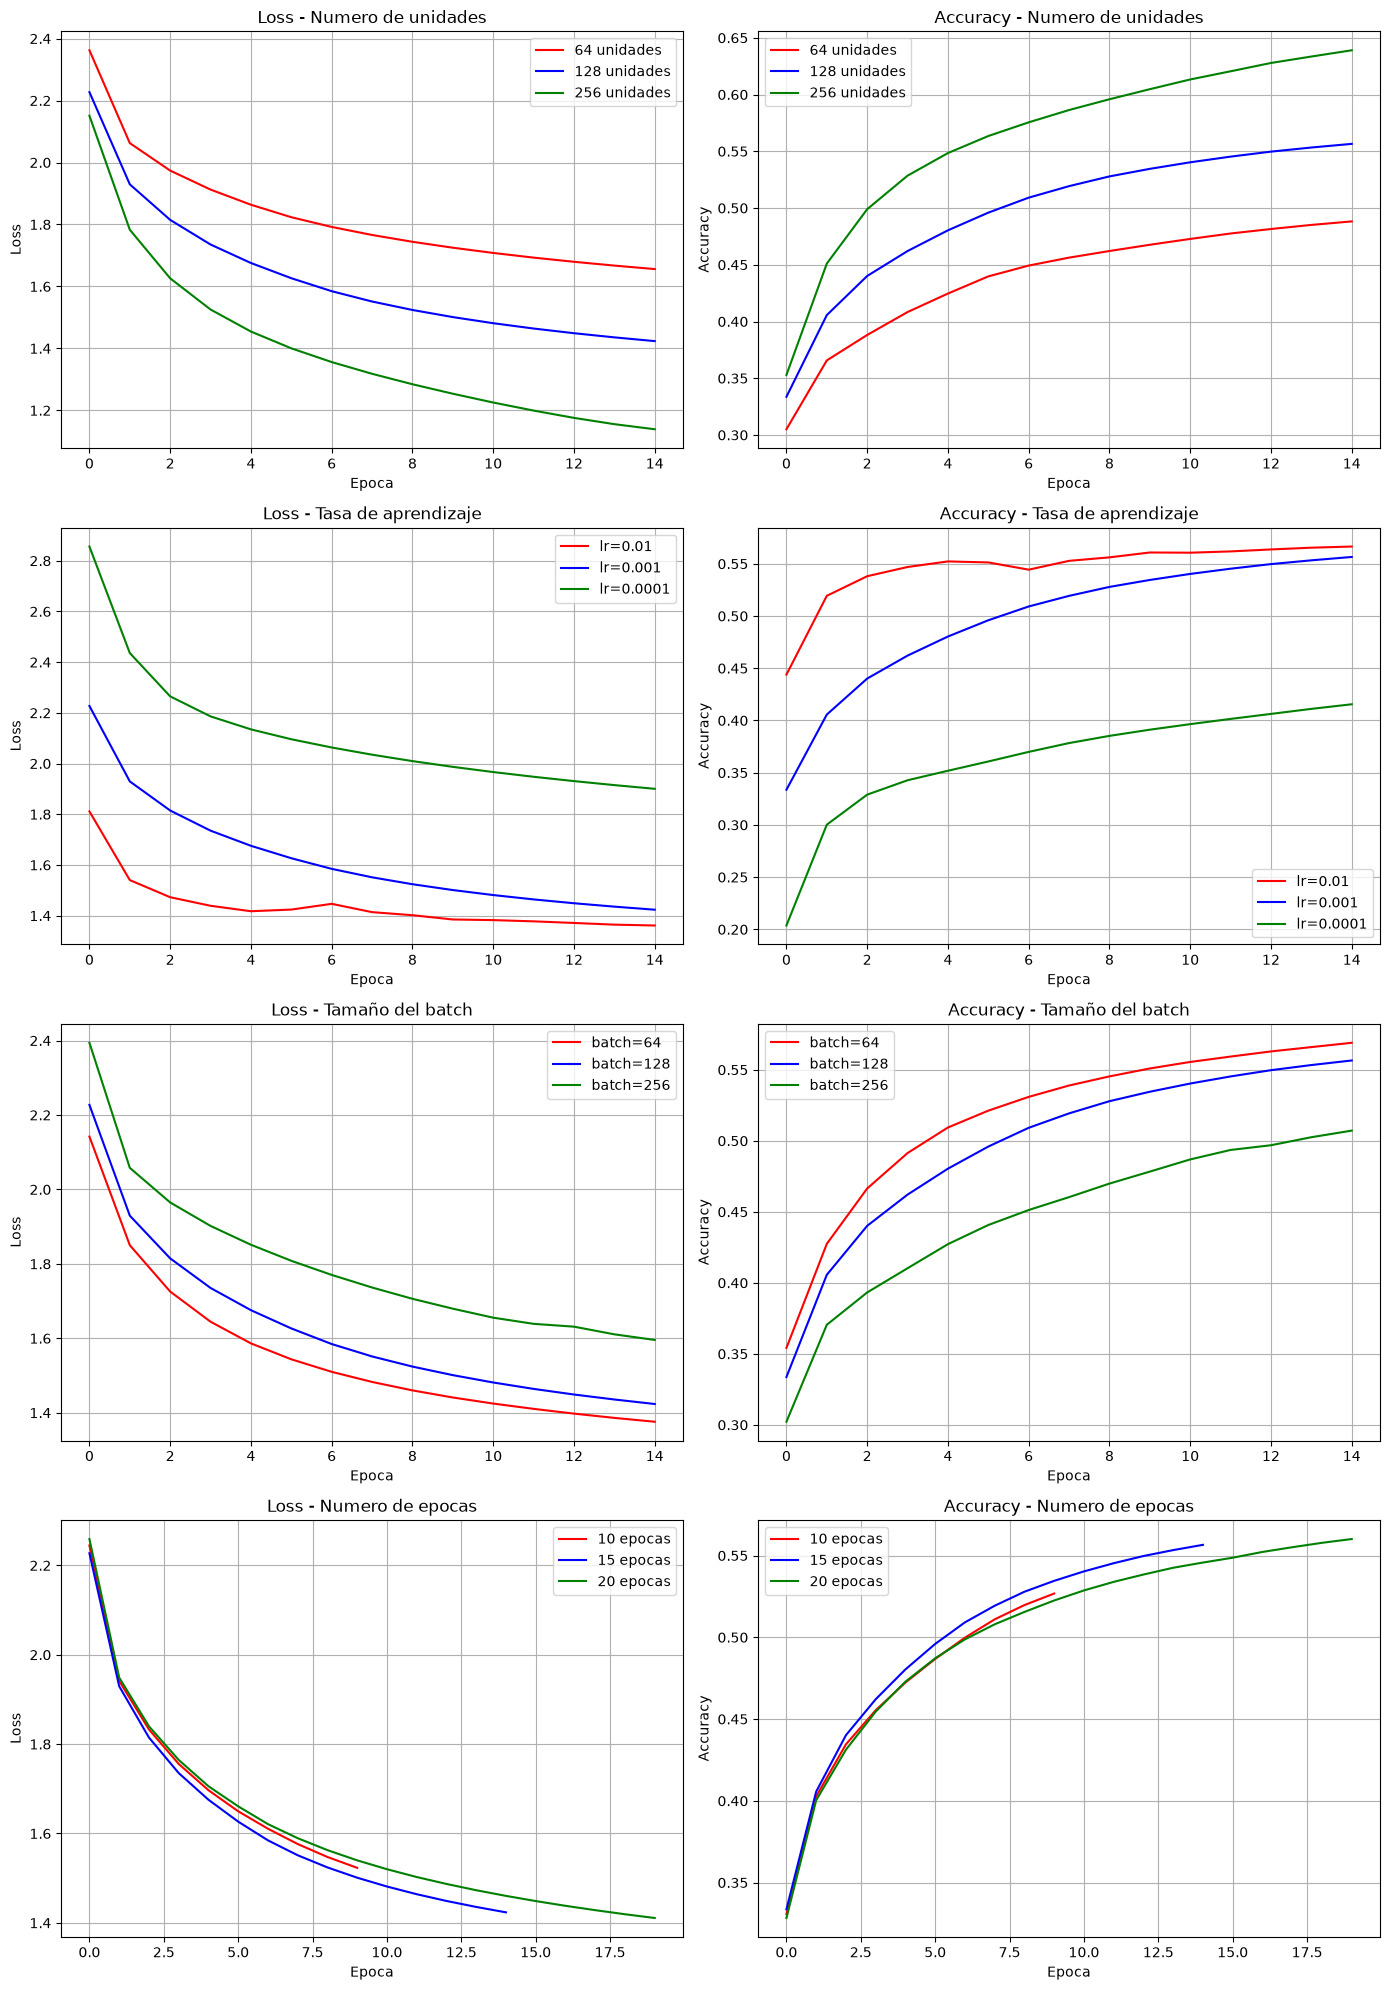

In [ ]:
# Graficos de Loss y Accuracy por experimento

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# Experimento 1: Unidades
axes[0][0].plot(res_64['history'].history['loss'], label='64 unidades', color='red')
axes[0][0].plot(history_lstm.history['loss'], label='128 unidades', color='blue')
axes[0][0].plot(res_256['history'].history['loss'], label='256 unidades', color='green')
axes[0][0].set_title('Loss - Numero de unidades')
axes[0][0].set_xlabel('Epoca')
axes[0][0].set_ylabel('Loss')
axes[0][0].legend()
axes[0][0].grid(True)

axes[0][1].plot(res_64['history'].history['accuracy'], label='64 unidades', color='red')
axes[0][1].plot(history_lstm.history['accuracy'], label='128 unidades', color='blue')
axes[0][1].plot(res_256['history'].history['accuracy'], label='256 unidades', color='green')
axes[0][1].set_title('Accuracy - Numero de unidades')
axes[0][1].set_xlabel('Epoca')
axes[0][1].set_ylabel('Accuracy')
axes[0][1].legend()
axes[0][1].grid(True)

# Experimento 2: Tasa de aprendizaje
axes[1][0].plot(res_lr_high['history'].history['loss'], label='lr=0.01', color='red')
axes[1][0].plot(history_lstm.history['loss'], label='lr=0.001', color='blue')
axes[1][0].plot(res_lr_low['history'].history['loss'], label='lr=0.0001', color='green')
axes[1][0].set_title('Loss - Tasa de aprendizaje')
axes[1][0].set_xlabel('Epoca')
axes[1][0].set_ylabel('Loss')
axes[1][0].legend()
axes[1][0].grid(True)

axes[1][1].plot(res_lr_high['history'].history['accuracy'], label='lr=0.01', color='red')
axes[1][1].plot(history_lstm.history['accuracy'], label='lr=0.001', color='blue')
axes[1][1].plot(res_lr_low['history'].history['accuracy'], label='lr=0.0001', color='green')
axes[1][1].set_title('Accuracy - Tasa de aprendizaje')
axes[1][1].set_xlabel('Epoca')
axes[1][1].set_ylabel('Accuracy')
axes[1][1].legend()
axes[1][1].grid(True)

# Experimento 3: Batch size
axes[2][0].plot(res_b64['history'].history['loss'], label='batch=64', color='red')
axes[2][0].plot(history_lstm.history['loss'], label='batch=128', color='blue')
axes[2][0].plot(res_b256['history'].history['loss'], label='batch=256', color='green')
axes[2][0].set_title('Loss - Tamaño del batch')
axes[2][0].set_xlabel('Epoca')
axes[2][0].set_ylabel('Loss')
axes[2][0].legend()
axes[2][0].grid(True)

axes[2][1].plot(res_b64['history'].history['accuracy'], label='batch=64', color='red')
axes[2][1].plot(history_lstm.history['accuracy'], label='batch=128', color='blue')
axes[2][1].plot(res_b256['history'].history['accuracy'], label='batch=256', color='green')
axes[2][1].set_title('Accuracy - Tamaño del batch')
axes[2][1].set_xlabel('Epoca')
axes[2][1].set_ylabel('Accuracy')
axes[2][1].legend()
axes[2][1].grid(True)

# Experimento 4: Epocas
axes[3][0].plot(res_ep10['history'].history['loss'], label='10 epocas', color='red')
axes[3][0].plot(history_lstm.history['loss'], label='15 epocas', color='blue')
axes[3][0].plot(res_ep20['history'].history['loss'], label='20 epocas', color='green')
axes[3][0].set_title('Loss - Numero de epocas')
axes[3][0].set_xlabel('Epoca')
axes[3][0].set_ylabel('Loss')
axes[3][0].legend()
axes[3][0].grid(True)

axes[3][1].plot(res_ep10['history'].history['accuracy'], label='10 epocas', color='red')
axes[3][1].plot(history_lstm.history['accuracy'], label='15 epocas', color='blue')
axes[3][1].plot(res_ep20['history'].history['accuracy'], label='20 epocas', color='green')
axes[3][1].set_title('Accuracy - Numero de epocas')
axes[3][1].set_xlabel('Epoca')
axes[3][1].set_ylabel('Accuracy')
axes[3][1].legend()
axes[3][1].grid(True)

plt.tight_layout()
plt.show()

## Analisis del impacto de los hiperparametros

**Numero de unidades (64 vs 128 vs 256):**
Aumentar las unidades mejora todas las metricas. Con 256 unidades se obtuvo el mejor accuracy (0.6155) y F1 (0.4283), mientras que con 64 el rendimiento bajo bastante (F1: 0.2326). Esto indica que el modelo necesita suficiente capacidad para capturar los patrones del texto.

**Tasa de aprendizaje (0.01 vs 0.001 vs 0.0001):**
El hiperparametro con mayor efecto. Con lr=0.0001 el modelo casi no aprendio (F1: 0.1593) porque los pasos de actualizacion son demasiado pequenos para 15 epocas. Con lr=0.01 se obtuvo un F1 levemente mejor que el valor base (0.3721 vs 0.3398).

**Tamaño del batch (64 vs 128 vs 256):**
Batches mas chicos dieron mejores resultados (batch=64: F1 0.3653) frente a batches grandes (batch=256: F1 0.2487). Al actualizar los pesos con mas frecuencia, el modelo converge mejor en la cantidad de epocas disponibles.

**Numero de epocas (10 vs 15 vs 20):**
Mas epocas mejoran los resultados pero cada vez menos. El salto de 10 a 15 fue notable (F1: 0.2739 a 0.3398), pero de 15 a 20 fue menor (0.3398 a 0.3613), indicando que el modelo se acerca a su punto de convergencia.

## Seleccion del modelo final

Segun la tabla de resultados, la configuracion con mejor desempeno fue LSTM con 256 unidades (accuracy: 0.6155, F1: 0.4283). Se entrena el modelo final con esta configuracion.

In [ ]:
# Entrenamiento del modelo final con la mejor configuracion
model_final = Sequential()
model_final.add(LSTM(256, input_shape=(SEQ_LENGTH, NUM_CHARS)))
model_final.add(Dense(NUM_CHARS, activation='softmax'))
model_final.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


def on_epoch_end_final(epoch, logs):
    print("\n\n\n")
    start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
    seed_text = text[start_pos:start_pos + SEQ_LENGTH]
    for temperature in TEMPERATURES_TO_TRY:
        print("------> Epoch: {} - Generando texto con temperature {}".format(
            epoch + 1, temperature))
        generated_text = generate_text(seed_text, model_final,
                                       GENERATED_TEXT_LENGTH, temperature)
        print("Seed: {}".format(seed_text))
        print("Texto generado: {}".format(generated_text))
        print()

callback_final = LambdaCallback(on_epoch_end=on_epoch_end_final)

history_final = model_final.fit(X, y, batch_size=128, epochs=15, callbacks=[callback_final])

Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2927 - loss: 2.4479



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: en la venta a toda la cuadrill
Texto generado: en la venta a toda la cuadrille de la contendo en el per en en la verte de la hande de la dentado de la canter a la conter a la canter a la verta de la verta de la meran en la caballero de la merando en el caballar a la caballer a la caballero de la verta de la vertar en esta la de la de la verció de la verta a la caballeros y e

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: en la venta a toda la cuadrill
Texto generado: en la venta a toda la cuadriller el sunmande en la meran con ton den sancho en en a se la bereles de la de la des la habar tra me sabía de la crielle a la hecer de la cabra de verroción la las cantondió de lo dellar a la lon canren la harminos, y venció en res les de la desto en el sañora en de las pabal de la habre de la fancan

------> Epoch: 1 - Generando

## Generacion de texto

Como ultimo paso, se a de verificar el comportamiento del modelo, generando predicciones y asi ver el resultado final

In [ ]:
# Generamos texto final con el mejor modelo
start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
seed = text[start_pos:start_pos + SEQ_LENGTH]

texto_final = generate_text(seed, model_final, 400, temperature=0.5)
print("Semilla:", repr(seed))
print("Texto generado:", texto_final)

Semilla: 'ue\nos dejase una mínima parte '
Texto generado: ue
os dejase una mínima parte de la silla, y no lo había contentros, y no se le digase, que no se ha de conocimiento, y así los diciendo las partes de la caballería, y debía en el mundo.

-no es más el dicho en el manto al mierro, y con la altenciad de la primera partida con la parte de la mancha, y de la tierra, y la cueva de modo que aquella descubrieron para los desgracias de las manos juntosas para contento el alterio a la


## Resultados del texto generado

El modelo genera palabras reales en español y mantiene estructuras gramaticales basicas. Se observa vocabulario propio del Quijote como "caballeros andantes" y "vuestra merced". La coherencia semantica es limitada, pero es esperable para un modelo a nivel de caracteres y cumple el objetivo planteado por el enunciado.

## Posibles mejoras a aplicar
- Agregar una segunda capa LSTM para capturar patrones mas complejos en el texto.
- Usar Dropout entre capas para reducir el sobreajuste.
- Aumentar SEQ_LENGTH para darle mas contexto al modelo al predecir.
- Implementar EarlyStopping con un conjunto de validacion para detener el entrenamiento en el punto optimo.